In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "JPM",
    "XOM",
    "JNJ",
    "KO"
]

prices = yf.download(
    TICKERS,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171755,15.4260,26.227922,75.737373,45.838100,29.215921,77.705750,39.607185,0.481884,56.777916
2015-01-05,23.490797,15.1095,25.728178,75.208389,44.415054,29.215921,76.457710,39.242970,0.473745,55.224369
2015-01-06,23.493013,14.7645,25.093220,74.838837,43.263424,29.437778,75.427582,38.666981,0.459382,54.930763
2015-01-07,23.822433,14.9210,25.019423,76.490990,43.329449,29.805244,75.427582,39.158264,0.458185,55.487373
2015-01-08,24.737751,15.0230,25.106590,77.092407,44.297703,30.165754,77.438316,40.310223,0.475420,56.410934


In [55]:
print(prices.shape)
print(prices.index.min())
print(prices.index.max())
print(prices.isna().sum())

(2766, 10)
2015-01-02 00:00:00
2025-12-31 00:00:00
Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
NVDA     0
XOM      0
dtype: int64


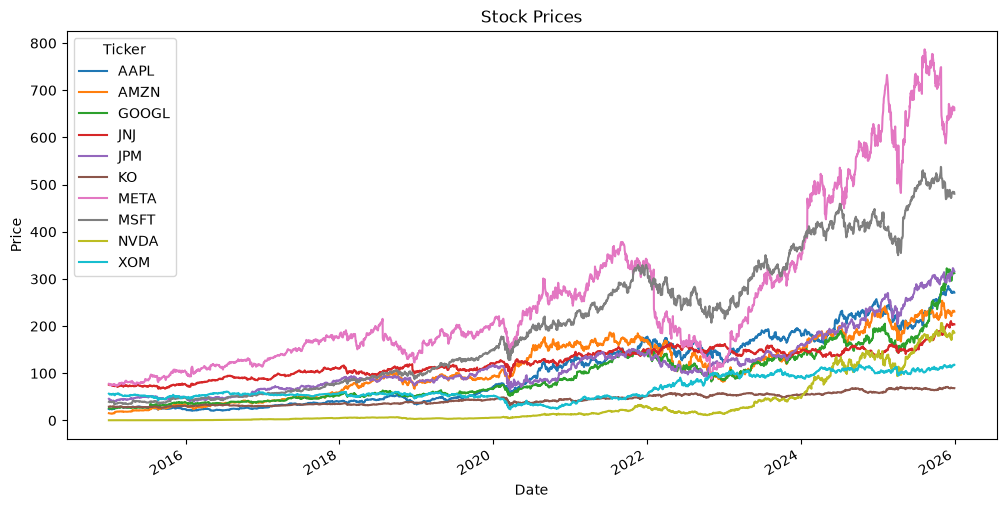

In [56]:
prices.plot(figsize=(12, 6))
plt.title("Stock Prices")
plt.ylabel("Price")
plt.show()

In [57]:
weekly_prices = prices.resample("W-FRI").last()
weekly_prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171755,15.4260,26.227922,75.737373,45.838100,29.215921,77.705750,39.607185,0.481884,56.777916
2015-01-09,24.764278,14.8465,24.800007,76.041740,43.527500,29.832972,77.002495,39.971397,0.477335,56.331413
2015-01-16,23.433315,14.5370,25.282419,75.389549,41.026161,29.486317,74.466789,39.166725,0.477814,55.732018
2015-01-23,24.978731,15.6195,26.842077,74.056244,41.576313,30.027100,77.091644,39.962917,0.495768,55.591351
2015-01-30,25.902893,17.7265,26.624151,72.563538,39.889194,28.543413,75.189850,34.220066,0.459621,53.468975


In [58]:
weekly_returns = weekly_prices.pct_change()
weekly_returns = weekly_returns.dropna()
weekly_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-09,0.024513,-0.037566,-0.054443,0.004019,-0.050408,0.021120,-0.009050,0.009196,-0.009439,-0.007864
2015-01-16,-0.053745,-0.020847,0.019452,-0.008577,-0.057466,-0.011620,-0.032930,-0.020131,0.001003,-0.010641
2015-01-23,0.065950,0.074465,0.061689,-0.017686,0.013410,0.018340,0.035249,0.020328,0.037575,-0.002524
2015-01-30,0.036998,0.134895,-0.008119,-0.020156,-0.040579,-0.049412,-0.024669,-0.143705,-0.072912,-0.038178
2015-02-06,0.019114,0.055708,-0.006827,0.009587,0.064546,0.006801,-0.018970,0.049752,0.062500,0.054549


In [59]:
print(weekly_returns.shape)
print(weekly_returns.describe())

(574, 10)
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000  574.000000  574.000000  574.000000   
mean      0.004950    0.005603    0.005071    0.002002    0.004041   
std       0.038172    0.042036    0.038947    0.023539    0.036654   
min      -0.175306   -0.144583   -0.120286   -0.107230   -0.196420   
25%      -0.016868   -0.017605   -0.016887   -0.012206   -0.014771   
50%       0.005342    0.004609    0.005234    0.002241    0.005479   
75%       0.026640    0.029338    0.025930    0.016735    0.024922   
max       0.147331    0.185163    0.258060    0.089396    0.222606   

Ticker          KO        META        MSFT        NVDA         XOM  
count   574.000000  574.000000  574.000000  574.000000  574.000000  
mean      0.001815    0.004899    0.004892    0.012380    0.001983  
std       0.025318    0.048363    0.032785    0.063096    0.037565  
min      -0.209820   -0.236982   -0.143705   -0.200516   -0.200671  
25%      -0.01

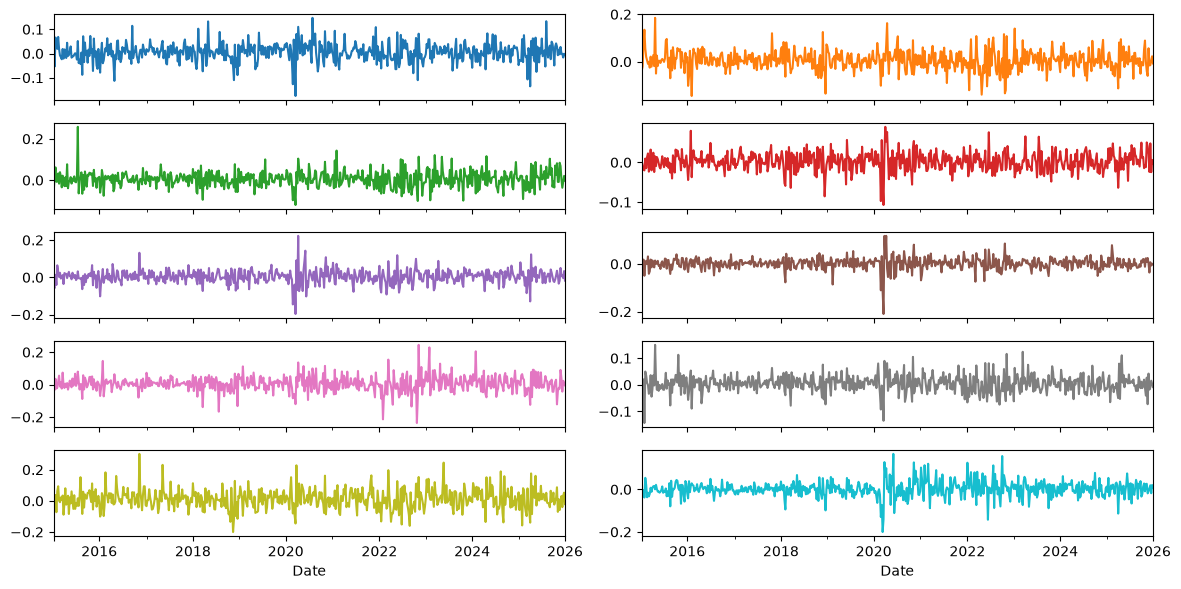

In [60]:
weekly_returns.plot(
    figsize=(12, 6),
    subplots=True,
    layout=(5, 2),
    legend=False
)

plt.tight_layout()
plt.show()

In [61]:
correlation = weekly_returns.corr()
print(correlation.round(2))

Ticker  AAPL  AMZN  GOOGL   JNJ   JPM    KO  META  MSFT  NVDA   XOM
Ticker                                                             
AAPL    1.00  0.48   0.54  0.31  0.36  0.37  0.41  0.57  0.48  0.18
AMZN    0.48  1.00   0.58  0.15  0.31  0.14  0.50  0.61  0.52  0.11
GOOGL   0.54  0.58   1.00  0.24  0.36  0.31  0.51  0.62  0.45  0.21
JNJ     0.31  0.15   0.24  1.00  0.33  0.51  0.13  0.31  0.14  0.29
JPM     0.36  0.31   0.36  0.33  1.00  0.43  0.31  0.38  0.36  0.51
KO      0.37  0.14   0.31  0.51  0.43  1.00  0.21  0.38  0.18  0.36
META    0.41  0.50   0.51  0.13  0.31  0.21  1.00  0.55  0.42  0.12
MSFT    0.57  0.61   0.62  0.31  0.38  0.38  0.55  1.00  0.60  0.19
NVDA    0.48  0.52   0.45  0.14  0.36  0.18  0.42  0.60  1.00  0.16
XOM     0.18  0.11   0.21  0.29  0.51  0.36  0.12  0.19  0.16  1.00


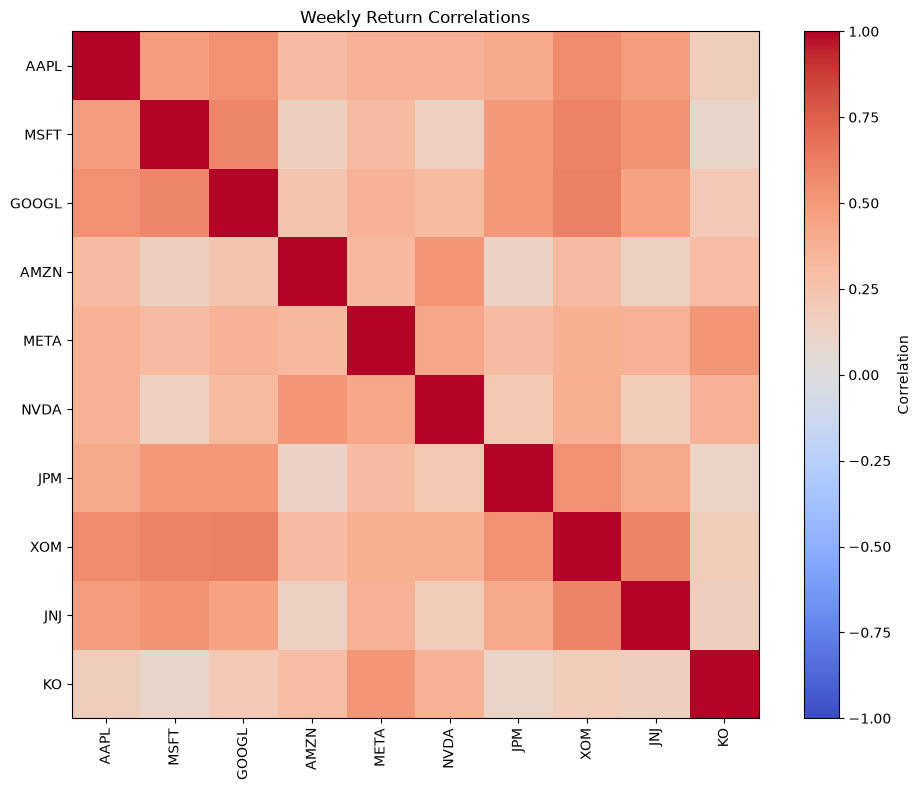

In [62]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(
    range(len(TICKERS)),
    TICKERS,
    rotation=90
)

plt.yticks(
    range(len(TICKERS)),
    TICKERS
)

plt.colorbar(label="Correlation")

plt.title("Weekly Return Correlations")
plt.tight_layout()
plt.show()

In [63]:
covariance = weekly_returns.cov()

print(covariance.round(5))

Ticker     AAPL     AMZN    GOOGL      JNJ      JPM       KO     META  \
Ticker                                                                  
AAPL    0.00146  0.00077  0.00080  0.00028  0.00051  0.00036  0.00076   
AMZN    0.00077  0.00177  0.00095  0.00015  0.00048  0.00015  0.00102   
GOOGL   0.00080  0.00095  0.00152  0.00022  0.00052  0.00031  0.00096   
JNJ     0.00028  0.00015  0.00022  0.00055  0.00028  0.00031  0.00014   
JPM     0.00051  0.00048  0.00052  0.00028  0.00134  0.00040  0.00055   
KO      0.00036  0.00015  0.00031  0.00031  0.00040  0.00064  0.00026   
META    0.00076  0.00102  0.00096  0.00014  0.00055  0.00026  0.00234   
MSFT    0.00071  0.00084  0.00079  0.00024  0.00046  0.00032  0.00086   
NVDA    0.00116  0.00139  0.00110  0.00021  0.00084  0.00029  0.00127   
XOM     0.00026  0.00017  0.00031  0.00026  0.00071  0.00034  0.00021   

Ticker     MSFT     NVDA      XOM  
Ticker                             
AAPL    0.00071  0.00116  0.00026  
AMZN    0.00084

In [64]:
print(weekly_returns.shape)
print(weekly_returns.head())
print(weekly_returns.describe())

(574, 10)
Ticker          AAPL      AMZN     GOOGL       JNJ       JPM        KO  \
Date                                                                     
2015-01-09  0.024513 -0.037566 -0.054443  0.004019 -0.050408  0.021120   
2015-01-16 -0.053745 -0.020847  0.019452 -0.008577 -0.057466 -0.011620   
2015-01-23  0.065950  0.074465  0.061689 -0.017686  0.013410  0.018340   
2015-01-30  0.036998  0.134895 -0.008119 -0.020156 -0.040579 -0.049412   
2015-02-06  0.019114  0.055708 -0.006827  0.009587  0.064546  0.006801   

Ticker          META      MSFT      NVDA       XOM  
Date                                                
2015-01-09 -0.009050  0.009196 -0.009439 -0.007864  
2015-01-16 -0.032930 -0.020131  0.001003 -0.010641  
2015-01-23  0.035249  0.020328  0.037575 -0.002524  
2015-01-30 -0.024669 -0.143705 -0.072912 -0.038178  
2015-02-06 -0.018970  0.049752  0.062500  0.054549  
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000

In [65]:
weekly_returns.to_csv("../data/weekly_returns.csv")
weekly_prices.to_csv("../data/weekly_prices.csv")

In [66]:
# ============================================
# STEP 1: Create supervised learning dataset
# ============================================

import numpy as np
import pandas as pd

LOOKBACK = 12  # Use previous 12 weeks to predict the next week

X = []
y = []
dates = []

for i in range(LOOKBACK, len(weekly_returns)):
    
    # Previous 12 weeks of returns
    X.append(
        weekly_returns.iloc[i-LOOKBACK:i].values
    )
    
    # Next week's returns
    y.append(
        weekly_returns.iloc[i].values
    )
    
    # Date of the target week
    dates.append(
        weekly_returns.index[i]
    )

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", len(X))

X shape: (562, 12, 10)
y shape: (562, 10)
Number of samples: 562


In [68]:
# ============================================
# STEP 1.2: Chronological train/validation/test split
# ============================================

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

dates_train = dates[:train_end]
dates_val = dates[train_end:val_end]
dates_test = dates[val_end:]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDate ranges:")
print("Train:", dates_train[0], "to", dates_train[-1])
print("Validation:", dates_val[0], "to", dates_val[-1])
print("Test:", dates_test[0], "to", dates_test[-1])

Training: (393, 12, 10) (393, 10)
Validation: (84, 12, 10) (84, 10)
Test: (85, 12, 10) (85, 10)

Date ranges:
Train: 2015-04-03 00:00:00 to 2022-10-07 00:00:00
Validation: 2022-10-14 00:00:00 to 2024-05-17 00:00:00
Test: 2024-05-24 00:00:00 to 2026-01-02 00:00:00


In [69]:
# Check for NaN values

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_val: 0
NaNs in y_val: 0
NaNs in X_test: 0
NaNs in y_test: 0


In [70]:
# ============================================
# STEP 2: Equal-Weight Portfolio Benchmark
# ============================================

N_ASSETS = y_test.shape[1]

# Equal weight for every stock
equal_weights = np.ones(N_ASSETS) / N_ASSETS

print("Number of assets:", N_ASSETS)
print("Weights:", equal_weights)
print("Sum of weights:", equal_weights.sum())

Number of assets: 10
Weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Sum of weights: 1.0


In [71]:
# ============================================
# Calculate equal-weight portfolio performance
# ============================================

# Portfolio return each test week
portfolio_returns_equal = y_test @ equal_weights

# Performance metrics
cumulative_return = np.prod(1 + portfolio_returns_equal) - 1

annualized_return = (
    np.prod(1 + portfolio_returns_equal)
    ** (52 / len(portfolio_returns_equal))
    - 1
)

annualized_volatility = (
    np.std(portfolio_returns_equal, ddof=1) * np.sqrt(52)
)

sharpe_ratio = (
    annualized_return / annualized_volatility
)

max_drawdown = (
    np.min(
        np.cumprod(1 + portfolio_returns_equal)
        / np.maximum.accumulate(np.cumprod(1 + portfolio_returns_equal))
        - 1
    )
)

print("Equal-Weight Portfolio — Test Set")
print("-----------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio:           {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Equal-Weight Portfolio — Test Set
-----------------------------------
Cumulative Return:     47.06%
Annualized Return:     26.61%
Annualized Volatility: 16.12%
Sharpe Ratio:           1.651
Maximum Drawdown:      -17.51%
